# Notebook 2: DEM Co-registration

Co-registers all DEMs to SRTM 2000 as reference using the Nuth and Kääb (2011) 
algorithm implemented in xDEM (xDEM Contributors, 2024).

Stable terrain masking: the union of 1975, 2000, and 2019 glacier outlines is 
used as the glacier mask, ensuring that formerly glaciated terrain is not 
misclassified as stable ground. For the IGM 1954 and Pléiades 2025 DEMs, 
artifact border areas were additionally masked by clipping to manually digitized 
validity polygons (following reviewer suggestion), substantially reducing 
stable-terrain NMAD.

INPUTS (from Notebook 1):
* aligned_dems_geoid/SRTM_2000_aligned.tif ← reference
* aligned_dems_geoid/<name>_aligned.tif for UAV and ASTER DEMs
* aligned_dems_clipped/THISFINAL_IGM_CLIPPED_DEM.tif ← clipped IGM
* aligned_dems_clipped/THISFINAL_PLEIADES_demCLIPPED.tif ← clipped Pléiades
* Glacier shapefiles (DGA 1975, 2000, and 2019)

OUTPUTS:
* coreg_dems_xdem/<name>_coreg.tif ← co-registered DEMs
* coreg_dems_xdem/coregistration_summary.csv
* coreg_dems_xdem/coregistration_qc.png

In [1]:
# ==============================================================================
# Imports and user variables
# ==============================================================================
import os
import shutil
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.warp import Resampling
import rioxarray as rxr
from rasterio.warp import Resampling as WarpResampling
import matplotlib.pyplot as plt
import xdem
import geoutils as gu

print(f'xDEM version: {xdem.__version__}')

aligned_dem_folder  = 'aligned_dems_geoid'
clipped_dem_folder  = 'aligned_dems_clipped'
output_folder       = 'coreg_dems_xdem'
os.makedirs(output_folder, exist_ok=True)

glacier_1975_path = '/Users/milliespencer/Desktop/70_Years_MB_Nevados/NdC_1975_glacier_poly/Shp/Nevados_Chillan_1975.shp'
glacier_2000_path = 'example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2000/Nevados_polygons_DGA2000.shp'
glacier_2019_path = 'example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2019/Nevados_polygons_DGA2019.shp'

reference_name = 'SRTM_2000'

# Source DEMs — IGM and Pléiades use clipped versions to remove border artifacts
source_dems = {
    'IGM_1954':         os.path.join(clipped_dem_folder, 'THISFINAL_IGM_CLIPPED_DEM.tif'),
    'CerroBlanco_2024': os.path.join(aligned_dem_folder, 'CerroBlanco_2024_aligned.tif'),
    'LasTermas_2024':   os.path.join(aligned_dem_folder, 'LasTermas_2024_aligned.tif'),
    'Pleiades_2025':    os.path.join(clipped_dem_folder, 'THISFINAL_PLEIADES_demCLIPPED.tif'),
    'ASTER_20180301':   os.path.join(aligned_dem_folder, 'ASTER_20180301_aligned.tif'),
}

xDEM version: 0.2.2


In [2]:
# ==============================================================================
# Step 1: Build glacier union mask
# Union of 1975 ∪ 2000 ∪ 2019 outlines — conservative masking so terrain
# that was ice in any inventory year is excluded from stable terrain.
# ==============================================================================
print('Building glacier union mask...')

gdf_1975 = gpd.read_file(glacier_1975_path)
gdf_2000 = gpd.read_file(glacier_2000_path)
gdf_2019 = gpd.read_file(glacier_2019_path)

gdf_2000 = gdf_2000.to_crs(gdf_1975.crs)
gdf_2019 = gdf_2019.to_crs(gdf_1975.crs)

glacier_union = gpd.GeoDataFrame(
    geometry=[gdf_1975.union_all()
                      .union(gdf_2000.union_all())
                      .union(gdf_2019.union_all())],
    crs=gdf_1975.crs
)
glacier_union_path = os.path.join(output_folder, 'glacier_union_mask.shp')
glacier_union.to_file(glacier_union_path)
print(f'  1975 area: {gdf_1975.area.sum()/1e6:.2f} km²')
print(f'  2000 area: {gdf_2000.to_crs("EPSG:32719").area.sum()/1e6:.2f} km²')
print(f'  2019 area: {gdf_2019.to_crs("EPSG:32719").area.sum()/1e6:.2f} km²')
print(f'  Union area: {glacier_union.area.sum()/1e6:.2f} km²')
print(f'  Saved: {glacier_union_path}')

Building glacier union mask...
  1975 area: 16.02 km²
  2000 area: 2.91 km²
  2019 area: 1.90 km²
  Union area: 16.34 km²
  Saved: coreg_dems_xdem/glacier_union_mask.shp


In [3]:
# ==============================================================================
# Step 2: Load reference DEM
# ==============================================================================
ref_path = os.path.join(aligned_dem_folder, f'{reference_name}_aligned.tif')
print(f'Loading reference DEM: {ref_path}')
reference_dem = xdem.DEM(ref_path)
print(f'  CRS: {reference_dem.crs}  |  Resolution: {reference_dem.res} m')

Loading reference DEM: aligned_dems_geoid/SRTM_2000_aligned.tif
  CRS: EPSG:32719  |  Resolution: (30.0, 30.0) m


In [4]:
# ==============================================================================
# Step 3: Create per-DEM stable terrain masks
#
# Stable terrain = non-glacier AND both source DEM and reference have valid data.
# Clipped DEMs are first reprojected to match the SRTM reference grid so that
# the stable terrain mask has the correct shape.
#
# Glacier mask used per DEM:
#   IGM 1954:            1975 ∪ 2000 ∪ 2019 — most conservative
#   SRTM 2000:           2000 ∪ 2019
#   CerroBlanco/LasTermas/Pleiades: 2019 only
#   ASTER:               2000 ∪ 2019
# ==============================================================================
print('Creating stable-terrain inlier masks...')

# Load reference DEM array for both-valid computation
with rasterio.open(ref_path) as src:
    ref_arr = src.read(1).astype(float)
    if src.nodata is not None:
        ref_arr[ref_arr == src.nodata] = np.nan
ref_arr[ref_arr < 0]    = np.nan
ref_arr[ref_arr > 7000] = np.nan
ref_valid = np.isfinite(ref_arr)

# Reference rioxarray for reprojection
ref_rxr = rxr.open_rasterio(ref_path, masked=True)

def build_glacier_mask(gdfs):
    union_geom = gdfs[0].to_crs(reference_dem.crs).union_all()
    for gdf in gdfs[1:]:
        union_geom = union_geom.union(gdf.to_crs(reference_dem.crs).union_all())
    union_gdf = gpd.GeoDataFrame(geometry=[union_geom], crs=reference_dem.crs)
    mask = gu.Vector(union_gdf).create_mask(reference_dem)
    return np.array(mask.data).squeeze().astype(bool)

aster_mask = build_glacier_mask([gdf_2000, gdf_2019])

glacier_masks = {
    'IGM_1954':         build_glacier_mask([gdf_1975, gdf_2000, gdf_2019]),
    'SRTM_2000':        build_glacier_mask([gdf_2000, gdf_2019]),
    'CerroBlanco_2024': build_glacier_mask([gdf_2019]),
    'LasTermas_2024':   build_glacier_mask([gdf_2019]),
    'Pleiades_2025':    build_glacier_mask([gdf_2019]),
    'ASTER_20180301':   aster_mask,
}

def make_stable_mask(dem_name, dem_path):
    # Reproject to reference grid if needed
    with rasterio.open(dem_path) as src:
        same_shape = (src.height == reference_dem.shape[0] and
                      src.width  == reference_dem.shape[1])

    if not same_shape:
        src_rxr = rxr.open_rasterio(dem_path, masked=True)
        matched = src_rxr.rio.reproject_match(ref_rxr, resampling=WarpResampling.bilinear)
        tmp_path = dem_path.replace('.tif', '_matched.tif')
        matched.rio.to_raster(tmp_path)
        read_path = tmp_path
    else:
        read_path = dem_path

    with rasterio.open(read_path) as src:
        arr = src.read(1).astype(float)
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    arr[arr < 0]    = np.nan
    arr[arr > 7000] = np.nan

    both_valid = np.isfinite(arr) & ref_valid
    stable_arr = both_valid & ~glacier_masks[dem_name]

    stable_raster = gu.Raster.from_array(
        data=stable_arr.astype(np.uint8),
        transform=reference_dem.transform,
        crs=reference_dem.crs,
        nodata=255,
    )
    stable_gu = stable_raster == 1

    pct = stable_arr.sum() / max(both_valid.sum(), 1) * 100
    print(f'  {dem_name:<20}: {stable_arr.sum():>10,} stable px  ({pct:.1f}% of footprint)')
    return stable_gu, stable_arr

inlier_masks = {}
for dem_name, dem_path in source_dems.items():
    inlier_masks[dem_name] = make_stable_mask(dem_name, dem_path)

Creating stable-terrain inlier masks...
  IGM_1954            :     38,941 stable px  (68.4% of footprint)
  CerroBlanco_2024    :      1,225 stable px  (63.3% of footprint)
  LasTermas_2024      :     12,311 stable px  (96.4% of footprint)
  Pleiades_2025       :     54,806 stable px  (96.3% of footprint)
  ASTER_20180301      :  7,048,792 stable px  (100.0% of footprint)


In [5]:
# ==============================================================================
# Step 4: Co-registration via xDEM NuthKaab + VerticalShift
#
# Uses our custom per-DEM inlier masks (Step 3) passed directly to xDEM,
# ensuring border artifacts and glacier areas are excluded from the
# co-registration fit. Clipped DEMs are reprojected to match SRTM grid
# before co-registration.
# ==============================================================================
os.makedirs(output_folder, exist_ok=True)

# Copy SRTM as its own coreg file (it is the reference)
shutil.copy(ref_path, os.path.join(output_folder, 'SRTM_2000_coreg.tif'))

summary_rows = []

print(f"\n{'DEM':<20} {'N stable':>10} {'Pre-med':>10} {'Pre-NMAD':>10} "
      f"{'Post-med':>10} {'Post-NMAD':>10}")
print('-' * 75)

for dem_name, dem_path in source_dems.items():
    out_path = os.path.join(output_folder, f'{dem_name}_coreg.tif')
    if os.path.exists(out_path):
        print(f'{dem_name}: already co-registered, skipping.')
        continue

    # Reproject clipped DEMs to reference grid
    with rasterio.open(dem_path) as src:
        same_shape = (src.height == reference_dem.shape[0] and
                      src.width  == reference_dem.shape[1])

    if not same_shape:
        src_rxr  = rxr.open_rasterio(dem_path, masked=True)
        matched  = src_rxr.rio.reproject_match(ref_rxr, resampling=WarpResampling.bilinear)
        tmp_path = dem_path.replace('.tif', '_matched.tif')
        matched.rio.to_raster(tmp_path)
        src_dem  = xdem.DEM(tmp_path)
    else:
        src_dem  = xdem.DEM(dem_path)

    inlier_mask_gu, inlier_mask_arr = inlier_masks[dem_name]

    # Pre-coreg stats
    dh_pre = np.array((reference_dem - src_dem).data).squeeze().astype(float)
    dh_pre[(dh_pre > 1e10) | (dh_pre < -1e4)] = np.nan
    dh_pre_stable = dh_pre[inlier_mask_arr & np.isfinite(dh_pre)]
    pre_med  = float(np.median(dh_pre_stable)) if len(dh_pre_stable) > 0 else np.nan
    pre_nmad = float(gu.stats.nmad(dh_pre_stable)) if len(dh_pre_stable) > 0 else np.nan
# Co-register
    if dem_name == 'CerroBlanco_2024':
        pipeline = xdem.coreg.VerticalShift()
    else:
        pipeline = xdem.coreg.NuthKaab() + xdem.coreg.VerticalShift()
    try:
        pipeline.fit(reference_dem, src_dem, inlier_mask=inlier_mask_gu)
        dem_coreg = pipeline.apply(src_dem)
        dem_coreg.save(out_path)
    except Exception as e:
        print(f'  {dem_name}: ERROR — {e}')
        continue
    
    # Post-coreg stats
    dh_post = np.array((reference_dem - dem_coreg).data).squeeze().astype(float)
    dh_post[(dh_post > 1e10) | (dh_post < -1e4)] = np.nan
    dh_post_stable = dh_post[inlier_mask_arr & np.isfinite(dh_post)]
    post_med  = float(np.median(dh_post_stable)) if len(dh_post_stable) > 0 else np.nan
    post_nmad = float(gu.stats.nmad(dh_post_stable)) if len(dh_post_stable) > 0 else np.nan

    status = '✓' if abs(post_med) < 3 else '⚠'
    print(f'  {dem_name:<20} {len(dh_post_stable):>10,} {pre_med:>10.3f} '
          f'{pre_nmad:>10.3f} {post_med:>10.3f} {post_nmad:>10.3f}  {status}')

    summary_rows.append({
        'DEM':            dem_name,
        'reference':      reference_name,
        'method':         'xdem_nuthkaab_verticalshift',
        'stable_pixels':  len(dh_post_stable),
        'pre_median_dh':  round(pre_med,   3),
        'pre_NMAD_m':     round(pre_nmad,  3),
        'post_median_dh': round(post_med,  3),
        'post_NMAD_m':    round(post_nmad, 3),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(output_folder, 'coregistration_summary.csv'), index=False)
print(f'\nSummary saved: {os.path.join(output_folder, "coregistration_summary.csv")}')


DEM                    N stable    Pre-med   Pre-NMAD   Post-med  Post-NMAD
---------------------------------------------------------------------------


/Users/milliespencer/miniconda3/envs/glacier-env/lib/python3.10/site-packages/xdem/coreg/affine.py:436: RuntimeWarning: overflow encountered in square
  slope_tan = np.sqrt(gradient_x**2 + gradient_y**2)
/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_35318/2959116980.py:56: DeprecationWarning: Call to deprecated function 'save'. The function .save() will be soon deprecated, use .to_file() instead. This functionality will be removed in version 0.3.0.
  dem_coreg.save(out_path)


  IGM_1954                 38,941     -4.439     13.873      0.154     11.304  ✓


/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_35318/2959116980.py:56: DeprecationWarning: Call to deprecated function 'save'. The function .save() will be soon deprecated, use .to_file() instead. This functionality will be removed in version 0.3.0.
  dem_coreg.save(out_path)


  CerroBlanco_2024          1,225      6.457     11.862      0.000     11.862  ✓


...

  LasTermas_2024           12,311     -3.806      5.593      0.000      4.861  ✓


/Users/milliespencer/miniconda3/envs/glacier-env/lib/python3.10/site-packages/xdem/coreg/affine.py:436: RuntimeWarning: overflow encountered in square
  slope_tan = np.sqrt(gradient_x**2 + gradient_y**2)
/Users/milliespencer/miniconda3/envs/glacier-env/lib/python3.10/site-packages/xdem/coreg/base.py:1038: OptimizeWarning: Covariance of the parameters could not be estimated
  results = params_fit_or_bin["fit_optimizer"](
/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_35318/2959116980.py:56: DeprecationWarning: Call to deprecated function 'save'. The function .save() will be soon deprecated, use .to_file() instead. This functionality will be removed in version 0.3.0.
  dem_coreg.save(out_path)


  Pleiades_2025            54,806      1.490      3.838      0.000      3.817  ✓


/Users/milliespencer/miniconda3/envs/glacier-env/lib/python3.10/site-packages/xdem/coreg/affine.py:436: RuntimeWarning: overflow encountered in square
  slope_tan = np.sqrt(gradient_x**2 + gradient_y**2)
/Users/milliespencer/miniconda3/envs/glacier-env/lib/python3.10/site-packages/xdem/coreg/base.py:1038: OptimizeWarning: Covariance of the parameters could not be estimated
  results = params_fit_or_bin["fit_optimizer"](
/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_35318/2959116980.py:56: DeprecationWarning: Call to deprecated function 'save'. The function .save() will be soon deprecated, use .to_file() instead. This functionality will be removed in version 0.3.0.
  dem_coreg.save(out_path)


  ASTER_20180301        7,048,792      5.247      6.276      0.189      5.829  ✓

Summary saved: coreg_dems_xdem/coregistration_summary.csv


Generating QC plots...


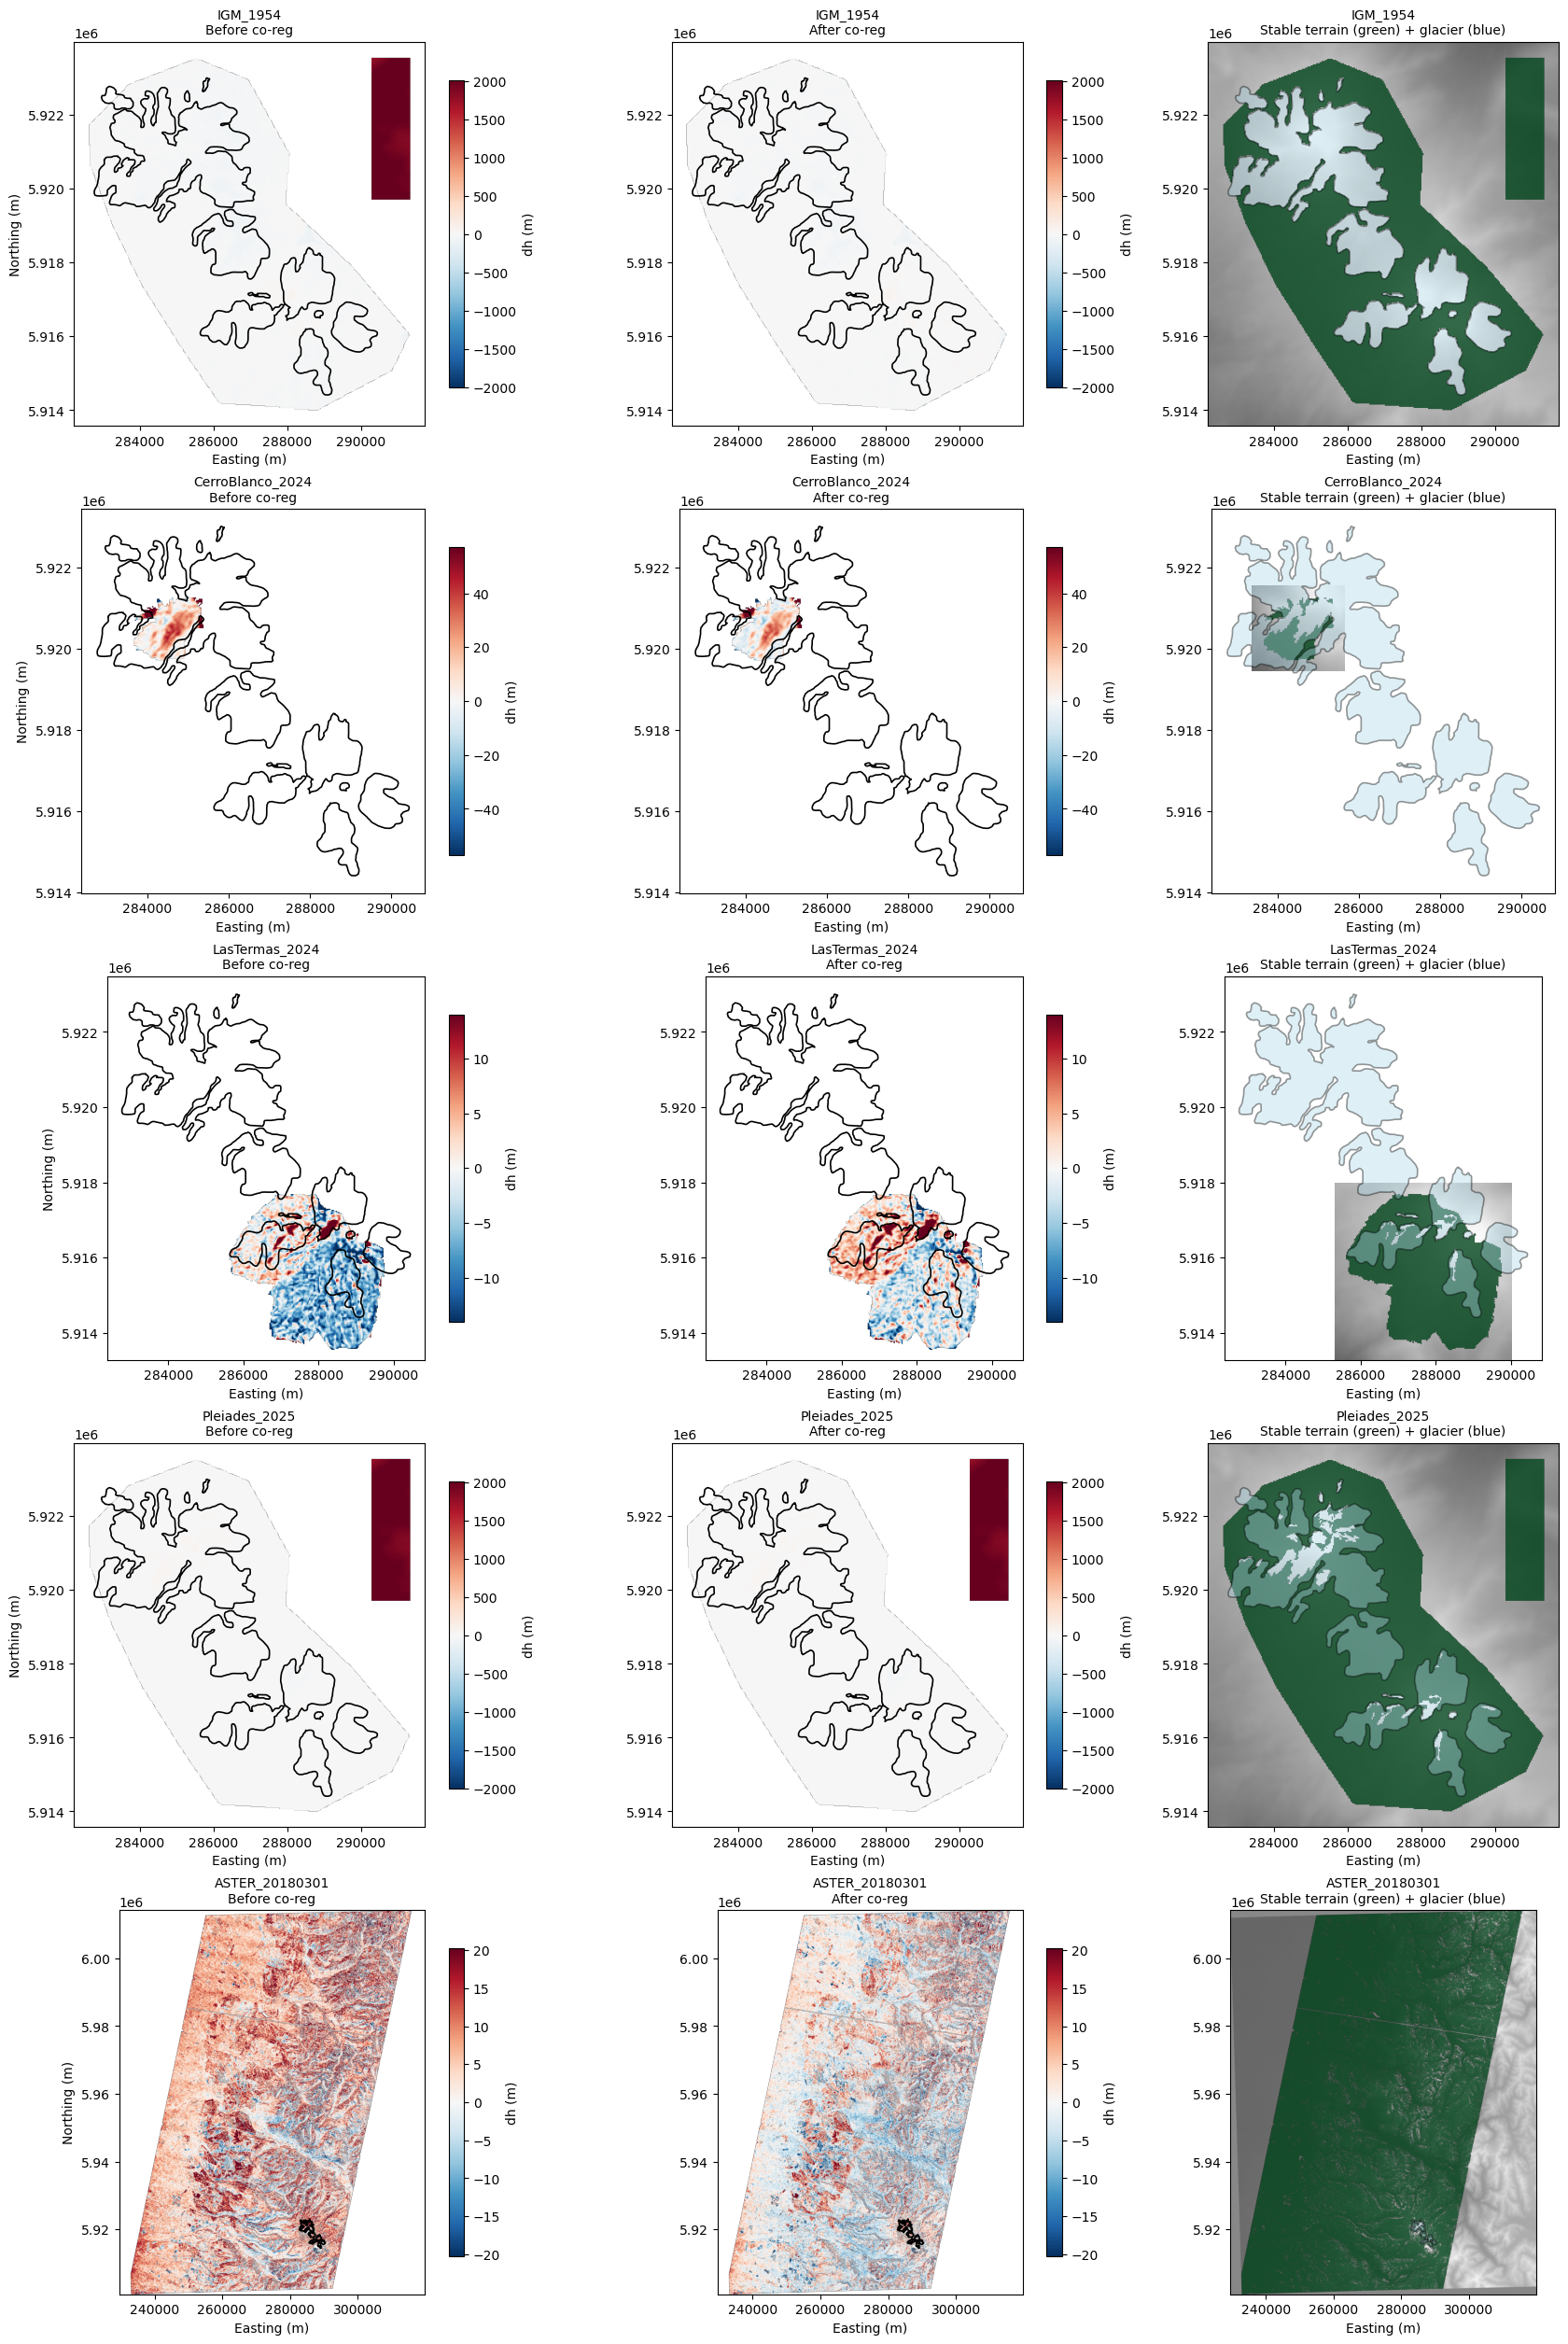

QC plot saved: coreg_dems_xdem/coregistration_qc.png


In [6]:
# =# ==============================================================================
# Step 5: QC plots
# Three columns per DEM:
#   Col 1: dh before co-registration
#   Col 2: dh after co-registration
#   Col 3: stable terrain mask (green) over reference DEM
# ==============================================================================
print('Generating QC plots...')

reference_rxr     = rxr.open_rasterio(ref_path, masked=True).squeeze()
glacier_union_gdf = gpd.read_file(glacier_union_path)

qc_dems = ['IGM_1954', 'CerroBlanco_2024', 'LasTermas_2024',
           'Pleiades_2025', 'ASTER_20180301']

fig, axes = plt.subplots(len(qc_dems), 3,
                          figsize=(18, 5 * len(qc_dems)),
                          constrained_layout=True)

ref_arr_plot = np.array(reference_dem.data).squeeze().astype(float)
ref_arr_plot[ref_arr_plot > 1e10] = np.nan
ref_arr_plot[ref_arr_plot < 0]    = np.nan

# Use reference bounds/transform for all plots
with rasterio.open(ref_path) as src:
    t, b, crs = src.transform, src.bounds, src.crs

for i, dem_name in enumerate(qc_dems):
    src_path   = source_dems[dem_name]
    coreg_path = os.path.join(output_folder, f'{dem_name}_coreg.tif')
    _, inlier_mask_arr = inlier_masks[dem_name]

    # Reproject source DEM to reference grid for differencing
    src_rxr_raw = rxr.open_rasterio(src_path, masked=True).squeeze()
    src_matched = src_rxr_raw.rio.reproject_match(
        reference_rxr, resampling=Resampling.bilinear)
    src_arr = src_matched.values.astype(float)
    src_arr[src_arr > 1e10] = np.nan
    src_arr[src_arr < 0]    = np.nan

    dem_c     = rxr.open_rasterio(coreg_path, masked=True).squeeze()
    coreg_arr = dem_c.rio.reproject_match(
        reference_rxr, resampling=Resampling.bilinear).values.astype(float)
    coreg_arr[coreg_arr > 1e10] = np.nan
    coreg_arr[coreg_arr < 0]    = np.nan

    dh_before = ref_arr_plot - src_arr
    dh_after  = ref_arr_plot - coreg_arr

    vr, vc = np.where(np.isfinite(dh_before))
    if len(vr) == 0:
        continue
    pad = lambda v, mn, mx: (max(v.min()-max(int((v.max()-v.min())*0.05),10), mn),
                              min(v.max()+max(int((v.max()-v.min())*0.05),10), mx))
    r0, r1 = pad(vr, 0, dh_before.shape[0])
    c0, c1 = pad(vc, 0, dh_before.shape[1])
    crop = [b.left+c0*t.a, b.left+c1*t.a, b.top+r1*t.e, b.top+r0*t.e]

    finite = dh_before[np.isfinite(dh_before)]
    clim   = float(np.nanpercentile(np.abs(finite), 95)) if len(finite) > 0 else 10.0
    gv     = glacier_union_gdf.to_crs(crs)

    for j, (data, title) in enumerate([
        (dh_before, f'{dem_name}\nBefore co-reg'),
        (dh_after,  f'{dem_name}\nAfter co-reg'),
    ]):
        ax = axes[i][j]
        im = ax.imshow(data[r0:r1,c0:c1], cmap='RdBu_r', vmin=-clim, vmax=clim,
                       extent=crop, origin='upper')
        gv.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.2)
        fig.colorbar(im, ax=ax, shrink=0.8, label='dh (m)')
        ax.set_title(title, fontsize=10)
        ax.set_xlabel('Easting (m)')
        if j == 0:
            ax.set_ylabel('Northing (m)')

    ax = axes[i][2]
    rc = ref_arr_plot[r0:r1,c0:c1].copy()
    rc[~np.isfinite(rc)] = np.nanmedian(ref_arr_plot[np.isfinite(ref_arr_plot)])
    ax.imshow(rc, cmap='gray', extent=crop, origin='upper', alpha=0.6)
    ax.imshow(np.where(inlier_mask_arr, 1.0, np.nan)[r0:r1,c0:c1],
              cmap='Greens', vmin=0, vmax=1, extent=crop, origin='upper', alpha=0.8)
    gv.plot(ax=ax, facecolor='lightblue', edgecolor='black', linewidth=1.2, alpha=0.4)
    ax.set_title(f'{dem_name}\nStable terrain (green) + glacier (blue)', fontsize=10)
    ax.set_xlabel('Easting (m)')

qc_path = os.path.join(output_folder, 'coregistration_qc.png')
fig.savefig(qc_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'QC plot saved: {qc_path}')

In [7]:
print('Notebook 2 complete.')
print(f'Co-registered DEMs saved to: {output_folder}')
print('Pass this folder to Notebook 3 for differencing and uncertainty analysis.')

Notebook 2 complete.
Co-registered DEMs saved to: coreg_dems_xdem
Pass this folder to Notebook 3 for differencing and uncertainty analysis.
